<a href="https://colab.research.google.com/github/anshuman183/Stock-Prediction/blob/main/Stock_price_prediction_using_stacked_LSTM_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Data Collection
import pandas_datareader as pdr

!pip install yfinance

In [11]:
import pandas as pd

# monkey patch
_old_concat = pd.concat

def fixed_concat(objs, axis=0, *args, **kwargs):
    return _old_concat(objs, axis=axis, *args, **kwargs)

pd.concat = fixed_concat

key='4c63493afc6c074900feb19844926902191f4305'
df = pdr.get_data_tiingo('AAPL',api_key=key)

In [12]:
df.to_csv('AAPL.csv')

In [13]:
import pandas as pd


In [14]:
df=pd.read_csv('AAPL.csv')

In [15]:
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2021-05-26 00:00:00+00:00,126.85,127.39,126.42,126.955,56575920,123.658238,124.184651,123.239058,123.760596,56575920,0.0,1.0
1,AAPL,2021-05-27 00:00:00+00:00,125.28,127.64,125.08,126.440,94625601,122.127742,124.428361,121.932775,123.258555,94625601,0.0,1.0
2,AAPL,2021-05-28 00:00:00+00:00,124.61,125.80,124.55,125.570,71311109,121.474601,122.634658,121.416110,122.410445,71311109,0.0,1.0
3,AAPL,2021-06-01 00:00:00+00:00,124.28,125.35,123.94,125.080,67637118,121.152904,122.195981,120.821459,121.932775,67637118,0.0,1.0
4,AAPL,2021-06-02 00:00:00+00:00,125.06,125.24,124.05,124.280,59278862,121.913278,122.088749,120.928691,121.152904,59278862,0.0,1.0


In [16]:
df1=df.reset_index()['close']

In [ ]:
np.max(df1)

0.9999999999999998

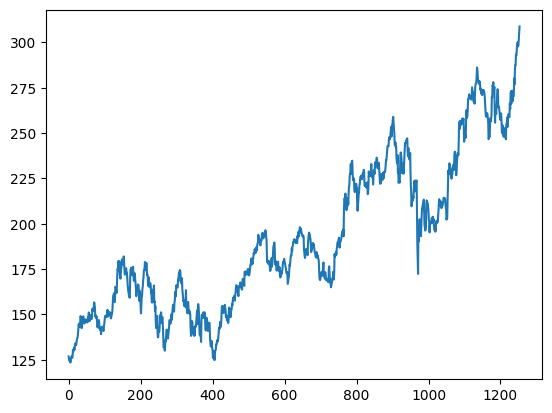

In [17]:
import matplotlib.pyplot as plt
plt.plot(df1)

In [ ]:
## LSTM are sensitive to the scale of the data. So we apply MinMax Scaler

In [18]:
import numpy as np

In [19]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df1=scaler.fit_transform(np.array(df1).reshape(-1,1))

In [20]:
df1.shape

(1254, 1)

In [21]:
## splitting dataset into train and test split
training_size = int(len(df1)*0.65)
test_size=len(df1)-training_size
train_data,test_data = df1[0:training_size,:],df1[training_size : len(df1), :1]

In [22]:
training_size , test_size

(815, 439)

In [23]:
import numpy
# convert an array of values into dataset matrix
def create_dataset(dataset,time_step=1):
  dataX,dataY = [] , []
  for i in range(len(dataset)-time_step-1):
    a = dataset[i:(i+time_step),0] ### i=0,1,2,3
    dataX.append(a)
    dataY.append(dataset[i + time_step,0])
  return numpy.array(dataX),numpy.array(dataY)

In [24]:
# reshape into X=t ,t+1 , t+2 , t+3 and Y=t+4
time_step = 100
X_train , y_train = create_dataset(train_data ,time_step)
X_test ,ytest = create_dataset(test_data,time_step)

In [25]:
print(X_train.shape), print(y_train.shape)

(714, 100)
(714,)


(None, None)

In [26]:
X_test

array([[0.54506693, 0.55753454, 0.5593696 , ..., 0.59833765, 0.59229275,
        0.61706606],
       [0.55753454, 0.5593696 , 0.56395725, ..., 0.59229275, 0.61706606,
        0.56519862],
       [0.5593696 , 0.56395725, 0.55564551, ..., 0.61706606, 0.56519862,
        0.57448187],
       ...,
       [0.80321675, 0.81104275, 0.80882988, ..., 0.94273532, 0.95363774,
        0.94073834],
       [0.81104275, 0.80882988, 0.81077288, ..., 0.95363774, 0.94073834,
        0.94683722],
       [0.80882988, 0.81077288, 0.80710276, ..., 0.94073834, 0.94683722,
        0.96454016]])

In [27]:
print(X_test.shape),print(ytest.shape)

(338, 100)
(338,)


(None, None)

In [28]:
# reshape input to be [samples , time steps , features] which is required for LSTM
X_train = X_train.reshape(X_train.shape[0],X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)


In [29]:
### Create the LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM


In [30]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(100,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
X_train[1]

array([[0.00939119],
       [0.00577504],
       [0.00399396],
       [0.0082038 ],
       [0.        ],
       [0.01268351],
       [0.01273748],
       [0.01727116],
       [0.01937608],
       [0.0138709 ],
       [0.02056347],
       [0.03745682],
       [0.03292314],
       [0.03567573],
       [0.0445272 ],
       [0.03734888],
       [0.04727979],
       [0.05634715],
       [0.05483592],
       [0.05327073],
       [0.05165155],
       [0.06066494],
       [0.06903066],
       [0.07243092],
       [0.07410406],
       [0.08862263],
       [0.09974093],
       [0.11350389],
       [0.10632556],
       [0.11641839],
       [0.11312608],
       [0.11927893],
       [0.13822323],
       [0.13460708],
       [0.12332686],
       [0.10206174],
       [0.12203152],
       [0.11798359],
       [0.12553972],
       [0.13503886],
       [0.13735967],
       [0.12537781],
       [0.11571675],
       [0.11927893],
       [0.12046632],
       [0.11863126],
       [0.12856218],
       [0.126

In [33]:
X_train[0]

array([[0.01786485],
       [0.00939119],
       [0.00577504],
       [0.00399396],
       [0.0082038 ],
       [0.        ],
       [0.01268351],
       [0.01273748],
       [0.01727116],
       [0.01937608],
       [0.0138709 ],
       [0.02056347],
       [0.03745682],
       [0.03292314],
       [0.03567573],
       [0.0445272 ],
       [0.03734888],
       [0.04727979],
       [0.05634715],
       [0.05483592],
       [0.05327073],
       [0.05165155],
       [0.06066494],
       [0.06903066],
       [0.07243092],
       [0.07410406],
       [0.08862263],
       [0.09974093],
       [0.11350389],
       [0.10632556],
       [0.11641839],
       [0.11312608],
       [0.11927893],
       [0.13822323],
       [0.13460708],
       [0.12332686],
       [0.10206174],
       [0.12203152],
       [0.11798359],
       [0.12553972],
       [0.13503886],
       [0.13735967],
       [0.12537781],
       [0.11571675],
       [0.11927893],
       [0.12046632],
       [0.11863126],
       [0.128

In [34]:
model.fit(X_train,y_train,validation_data=(X_test,ytest),epochs=100,batch_size=64,verbose=1)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 198ms/step - loss: 0.0228 - val_loss: 0.0587
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - loss: 0.0053 - val_loss: 0.0084
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 219ms/step - loss: 0.0033 - val_loss: 0.0125
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - loss: 0.0022 - val_loss: 0.0040
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - loss: 0.0019 - val_loss: 0.0036
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - loss: 0.0018 - val_loss: 0.0035
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - loss: 0.0018 - val_loss: 0.0033
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - loss: 0.0016 - val_loss: 0.0032
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - loss: 0.0016 - val_loss: 0.0030
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - loss: 0.0015 - val_loss: 0.0029
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - loss: 0.0014 - val_loss: 0.0029
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2

In [35]:
### Lets Do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict = model.predict(X_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [36]:
## Transformback to original form
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)


In [37]:
### Calculated RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

172.0810786431611

In [38]:
### Test data RMSE
math.sqrt(mean_squared_error(ytest,test_predict))

244.79023424173067

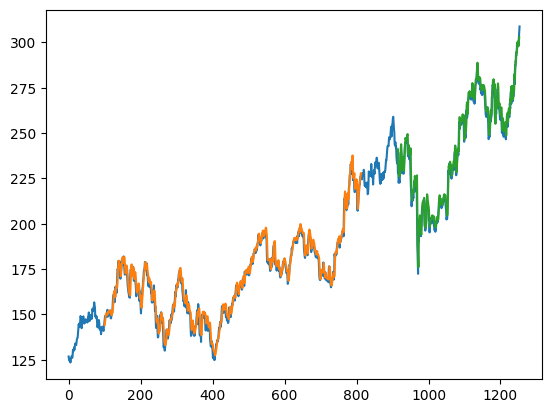

In [39]:
### Plotting
# shift train predictions for plotting
look_back = 100
trainPredictPlot = numpy.empty_like(df1)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict

#Shift test predictions for plotting

testPredictPlot = numpy.empty_like(df1)
testPredictPlot[: , :]=np.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df1)-1, :] = test_predict

#plot baseline and predictions

plt.plot(scaler.inverse_transform(df1))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()


In [40]:
X_test

array([[[0.54506693],
        [0.55753454],
        [0.5593696 ],
        ...,
        [0.59833765],
        [0.59229275],
        [0.61706606]],

       [[0.55753454],
        [0.5593696 ],
        [0.56395725],
        ...,
        [0.59229275],
        [0.61706606],
        [0.56519862]],

       [[0.5593696 ],
        [0.56395725],
        [0.55564551],
        ...,
        [0.61706606],
        [0.56519862],
        [0.57448187]],

       ...,

       [[0.80321675],
        [0.81104275],
        [0.80882988],
        ...,
        [0.94273532],
        [0.95363774],
        [0.94073834]],

       [[0.81104275],
        [0.80882988],
        [0.81077288],
        ...,
        [0.95363774],
        [0.94073834],
        [0.94683722]],

       [[0.80882988],
        [0.81077288],
        [0.80710276],
        ...,
        [0.94073834],
        [0.94683722],
        [0.96454016]]])

In [41]:
len(test_data)

439

In [47]:
x_input = test_data[339:].reshape(1,-1)
x_input.shape

(1, 100)

In [43]:
temp_input = list(x_input)
temp_input=temp_input[0].tolist()

In [44]:
temp_input

[0.7959304835924006,
 0.7756908462867012,
 0.7492443868739207,
 0.7382879965457685,
 0.7313255613126082,
 0.7331066493955096,
 0.7378562176165804,
 0.742174006908463,
 0.7362910189982728,
 0.7268458549222796,
 0.7123812607944733,
 0.6647236614853194,
 0.6698510362694301,
 0.6736291018998273,
 0.6719559585492227,
 0.7117335924006909,
 0.727169689119171,
 0.7172927461139897,
 0.7272236614853194,
 0.7337003454231434,
 0.7905332469775475,
 0.7876727115716755,
 0.8255073402417963,
 0.8223769430051815,
 0.8343048359240071,
 0.8154145077720207,
 0.8103411053540588,
 0.8201640759930915,
 0.7458441278065631,
 0.7137305699481866,
 0.7574481865284974,
 0.7599848877374786,
 0.7396373056994818,
 0.7612262521588946,
 0.7698618307426599,
 0.8020293609671847,
 0.8133095854922281,
 0.8064011226252159,
 0.7590673575129534,
 0.7619818652849744,
 0.7567465457685665,
 0.7501079447322969,
 0.7380721070811747,
 0.7227979274611398,
 0.7358592400690847,
 0.7409866148531952,
 0.740878670120898,
 0.7136226252158

In [53]:
import numpy as np # Ensure numpy is imported as np

# demonstrate prediction for next 10 days

from numpy import array

lst_output=[]
n_steps=100

# Re-initialize temp_input from x_input to ensure it has the correct starting length (n_steps=100).
# This addresses cases where x_input or temp_input might not have been correctly updated in preceding cells.
temp_input = x_input[0].tolist()

i=0
while(i<30):
  # Both branches should ensure x_input is prepared with the correct shape (1, n_steps, 1).
  if(len(temp_input)>n_steps):
    #print(temp_input)
    x_input=np.array(temp_input[1:])
    print("{} day input {}".format(i,x_input))
    x_input=x_input.reshape(1,-1)
    x_input= x_input.reshape((1,n_steps,1))
    #print(x_input)
    yhat=model.predict(x_input,verbose=0)
    print("{} day output {}".format(i,yhat))
    temp_input.extend(yhat[0].tolist())
    temp_input=temp_input[1:]
    # The predicted value yhat is already a 2D array (1,1), so append it directly
    lst_output.append(yhat.tolist()[0]) # yhat.tolist() gives [[value]], so append [value]
    i=i+1
  else:
    # In the else block, x_input needs to be explicitly created from temp_input
    # and reshaped to match the model's expected input shape (1, n_steps, 1).
    # Note: If len(temp_input) is not equal to n_steps (e.g., 98 vs 100),
    # this reshape will lead to a new ValueError: 'cannot reshape array of size N into shape (1,100,1)'
    # until the initial temp_input is corrected to be n_steps long.
    x_input_for_predict = np.array(temp_input).reshape(1, n_steps, 1)

    yhat = model.predict(x_input_for_predict , verbose=0)
    print(yhat[0])
    temp_input.extend(yhat[0].tolist())
    # After extending, remove the oldest element to maintain the window size.
    # This line assumes temp_input was already n_steps long or becomes n_steps+1 after extend.
    temp_input=temp_input[1:]
    print(len(temp_input))
    # The predicted value yhat is already a 2D array (1,1), so append it directly
    lst_output.append(yhat.tolist()[0]) # yhat.tolist() gives [[value]], so append [value]
    i=i+1


print(lst_output)


[1.0029292]
100
[1.0032772]
100
[1.000675]
100
[0.99758494]
100
[0.9950032]
100
[0.99305195]
100
[0.99152464]
100
[0.99023116]
100
[0.989127]
100
[0.9882938]
100
[0.98786336]
100
[0.98794496]
100
[0.9885885]
100
[0.9897786]
100
[0.9914481]
100
[0.99349797]
100
[0.9958147]
100
[0.9982838]
100
[1.0007964]
100
[1.003255]
100
[1.0055757]
100
[1.00769]
100
[1.0095487]
100
[1.0111194]
100
[1.0123883]
100
[1.0133588]
100
[1.0140492]
100
[1.0144892]
100
[1.0147179]
100
[1.0147803]
100
[[1.0029292106628418], [1.0032771825790405], [1.0006749629974365], [0.9975849390029907], [0.9950032234191895], [0.9930519461631775], [0.9915246367454529], [0.9902311563491821], [0.989126980304718], [0.9882938265800476], [0.9878633618354797], [0.9879449605941772], [0.9885885119438171], [0.9897785782814026], [0.9914481043815613], [0.9934979677200317], [0.9958146810531616], [0.9982838034629822], [1.0007964372634888], [1.003255009651184], [1.0055756568908691], [1.0076899528503418], [1.0095486640930176], [1.0111193656

In [55]:
day_new=np.arange(1,101)
day_pred=np.arange(101,131)

In [56]:
import matplotlib.pyplot as plt

In [57]:
len(df1)

1254

In [58]:
df3=df1.tolist()
df3.extend(lst_output)

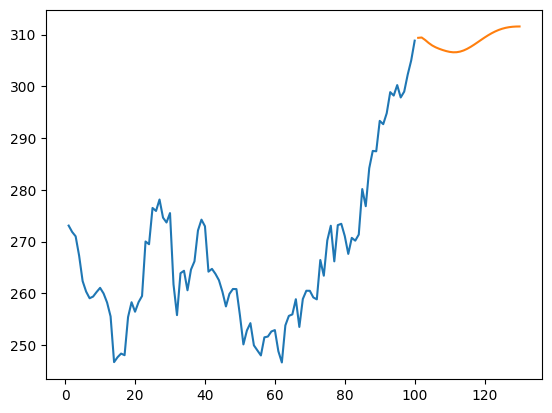

In [59]:
day_new=np.arange(1,101)
day_pred=np.arange(101,131)
plt.plot(day_new , scaler.inverse_transform(df1[1154:]))
plt.plot(day_pred, scaler.inverse_transform(lst_output))
plt.show()

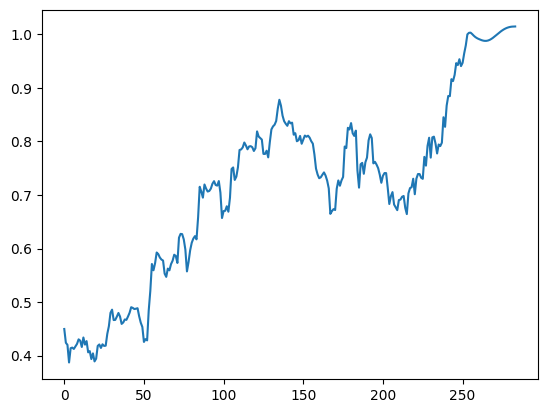

In [60]:
df3=df1.tolist()
df3.extend(lst_output)
plt.plot(df3[1000:])